# Magnificent 7 — Stock Analysis, Portfolio Optimization & Risk Forecasting

**Companies:** Apple (AAPL), Google (GOOG), Meta (META), Amazon (AMZN), Netflix (NFLX), NVIDIA (NVDA), Tesla (TSLA)

---

## Project Objective

End-to-end quantitative analysis of the Magnificent 7 tech stocks, structured into 7 sections:

1. Data Fetching — Live stock data via Yahoo Finance
2. Exploratory Data Analysis (EDA) — Price trends, moving averages
3. Risk & Return Analysis — Daily returns, volatility, Beta, correlation heatmap
4. Benchmark Comparison — Mag-7 vs S&P 500
5. CAPM Analysis — Expected vs actual returns, Alpha
6. Portfolio Optimization — Efficient Frontier (Modern Portfolio Theory)
7. Monte Carlo Risk Simulation — VaR, Rebalancing Backtest

---

> All data is fetched live from Yahoo Finance using yfinance.


## Importing Libraries


In [126]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
import warnings
import yfinance as yf

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

print('All libraries imported')

All libraries imported


##  Fetching Stock Data

We download 5 years of daily closing prices using yfinance.

Why 5 years? It captures multiple market cycles: COVID crash (2020), recovery (2021), rate hike selloff (2022), AI bull run (2023-2024).


In [127]:
tickers = ['AAPL', 'GOOG', 'META', 'AMZN', 'NFLX', 'NVDA', 'TSLA']
end_date = datetime.now()
start_date = end_date - pd.DateOffset(years=5)
data = yf.download(tickers, start=start_date, end=end_date ,auto_adjust=True)['Close']
print(f'Shape: {data.shape}')
print(f'Range: {data.index[0].date()} to {data.index[-1].date()}')
data.sample(5)

[*********************100%***********************]  7 of 7 completed

Shape: (1255, 7)
Range: 2021-05-28 to 2026-05-28


Ticker,AAPL,AMZN,GOOG,META,NFLX,NVDA,TSLA
Date,,,,,,,
2024-08-06,205.450302,161.929993,159.413910,491.250244,60.957001,104.199776,200.639999
2025-01-15,236.359894,223.350006,196.077988,614.653870,84.825996,136.195389,428.220001
2023-12-13,195.744308,148.839996,132.879074,332.133545,47.998001,48.058628,239.289993
2021-09-15,145.484924,173.789505,144.023575,371.008484,58.286999,22.293869,251.943329
2025-11-26,277.035278,229.160004,319.845825,632.552063,106.139999,180.240204,426.579987


##  Exploratory Data Analysis (EDA)

### Individual Closing Price Charts


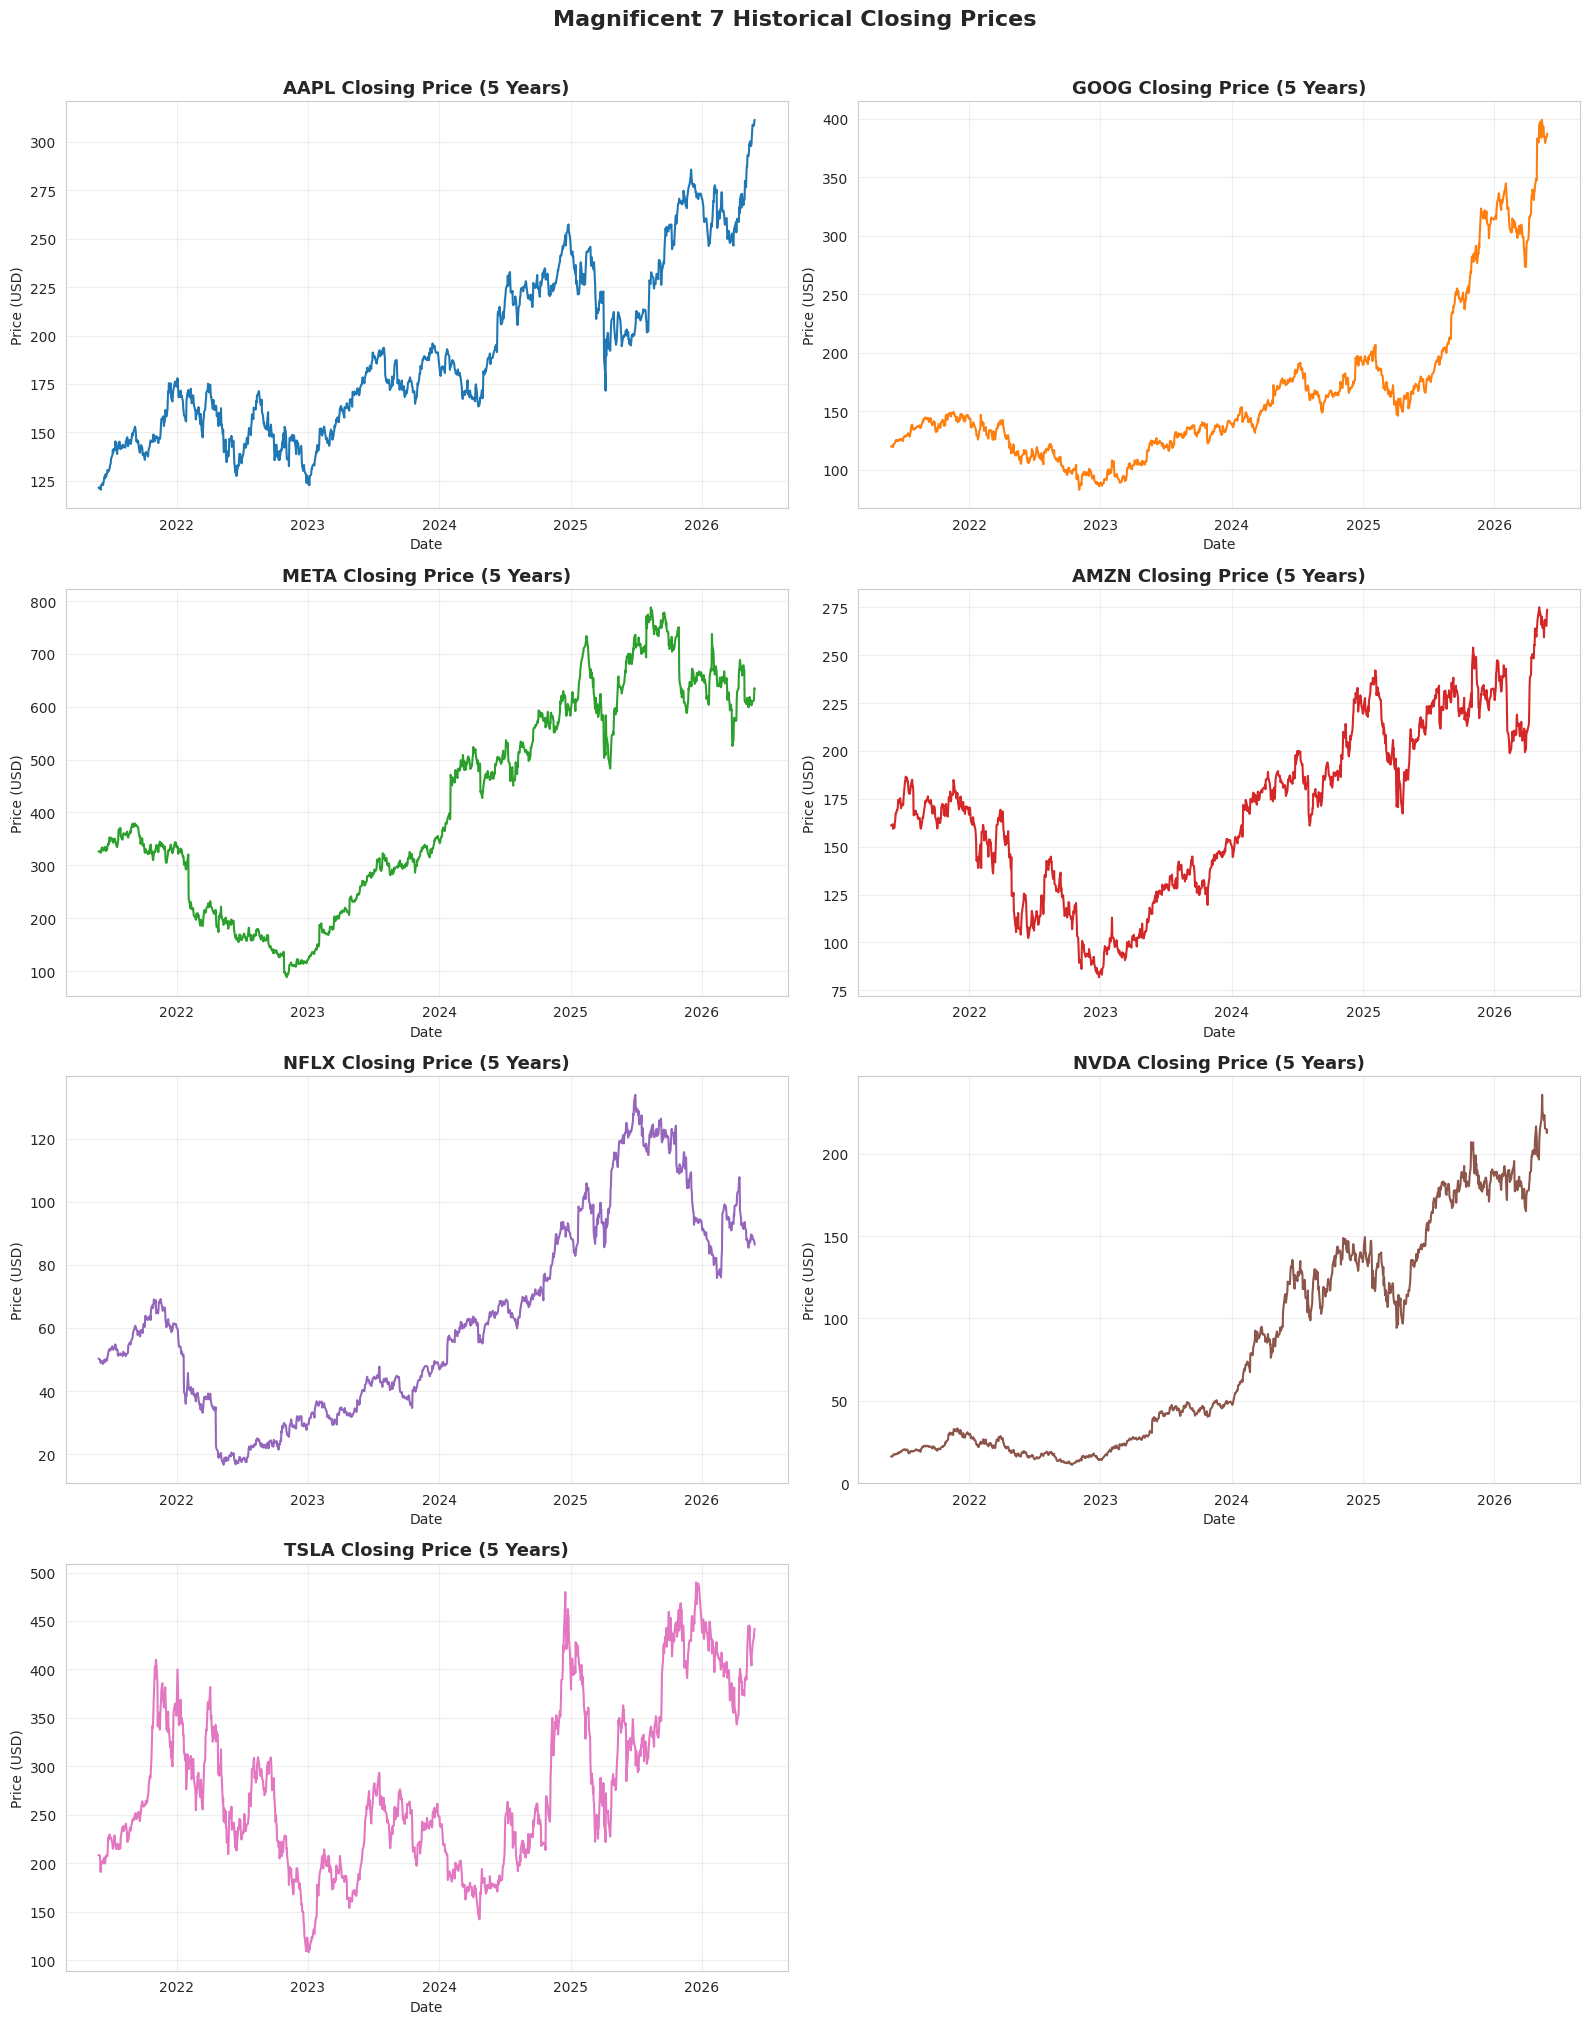

In [128]:
colors = sns.color_palette("tab10", len(tickers))

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].plot(data.index, data[ticker], color=colors[i], linewidth=1.5)
    axes[i].set_title(f'{ticker} Closing Price (5 Years)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price (USD)')
    axes[i].grid(True, alpha=0.3)

fig.delaxes(axes[7])
plt.suptitle('Magnificent 7 Historical Closing Prices', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Insights

- NVIDIA exhibited one of the strongest long-term upward trends, especially after 2023, reflecting strong market optimism around AI and semiconductor growth.

- Tesla showed the highest volatility among all Magnificent 7 stocks, with sharp upward and downward swings throughout the period, indicating a high-risk, high-reward profile.

- Meta experienced a major decline during 2022, followed by a very strong recovery phase during 2023–2025.

- Netflix also suffered a sharp correction in 2022 before gradually recovering over the following years.

- Amazon and Apple demonstrated relatively smoother long-term growth compared to highly volatile stocks like Tesla.

- Most stocks displayed significant recovery after the 2022 tech-market downturn.

- #### Since raw prices are plotted, direct performance comparison between stocks is limited because each stock started at different price levels.

###  Normalized Price Comparison (Base = 100)

Normalizing to 100 at start lets us compare percentage growth fairly across all stocks.

Formula: Normalized = (Price / First Price) x 100


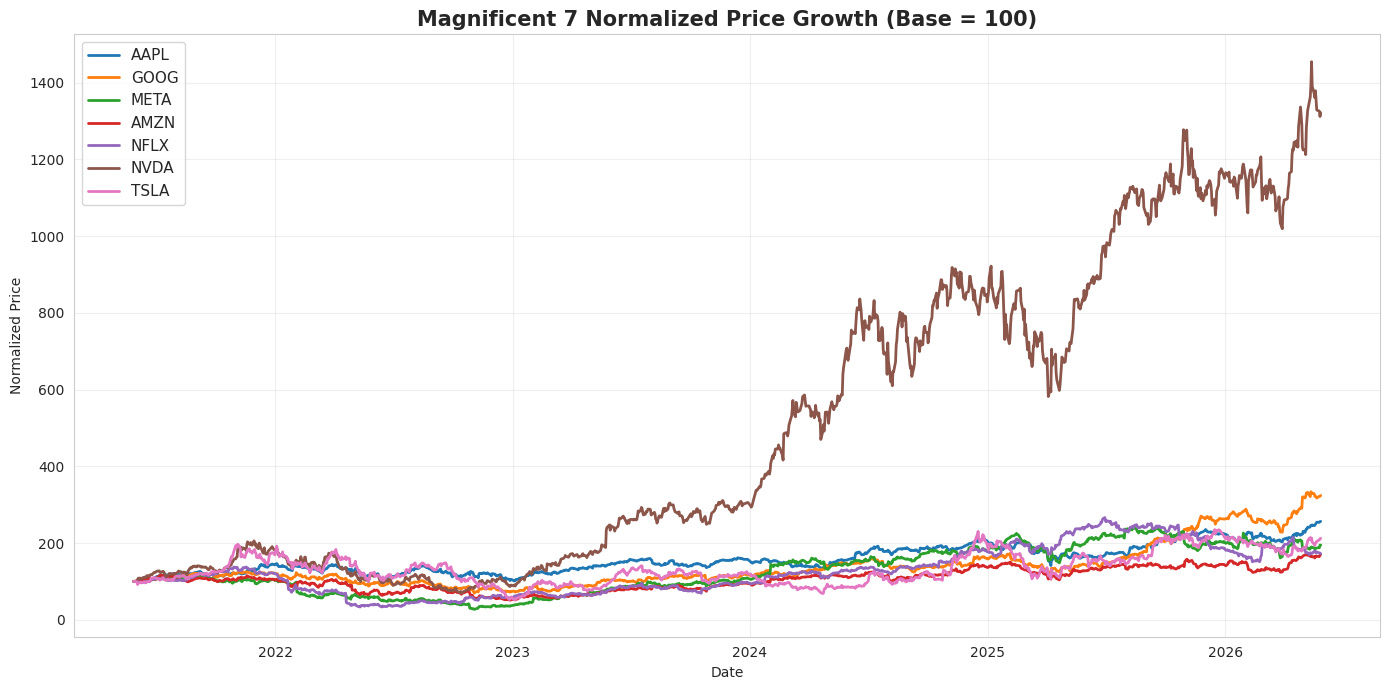

5-Year Total Return Summary:
----------------------------------------
  AAPL : +156.3%
  GOOG : +223.9%
  META : +94.5%
  AMZN : +69.9%
  NFLX : +71.9%
  NVDA : +1221.9%
  TSLA : +112.1%


In [129]:
normalized = (data / data.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for i, ticker in enumerate(tickers):
    plt.plot(normalized.index, normalized[ticker], label=ticker, color=colors[i], linewidth=2)

plt.title('Magnificent 7 Normalized Price Growth (Base = 100)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('5-Year Total Return Summary:')
print('-' * 40)
for ticker in tickers:
    r = ((data[ticker].iloc[-1] / data[ticker].iloc[0]) - 1) * 100
    print(f'  {ticker:5s}: {r:+.1f}%')

### Key Insights

- NVIDIA overwhelmingly outperformed all other Magnificent 7 stocks, driven by the rapid growth of the AI and semiconductor industry.

- The 2022 tech-market correction affected nearly all stocks, but most companies demonstrated strong recovery momentum afterward.

- Tesla showed the highest volatility throughout the period, highlighting its high-risk, high-reward investment profile.

- Apple delivered comparatively stable and consistent long-term growth with lower fluctuations than most growth-oriented tech stocks.

- Normalizing prices to a common base value of 100 enables fair comparison of cumulative growth across stocks with different initial price levels.

###  Moving Averages (Google deep dive)

Moving averages smooth short-term noise to reveal longer-term trends.

- 10-day MA: Short-term trend
- 25-day MA: Medium-term trend
- 50-day MA: Long-term sentiment indicator

- Golden Cross: MA_10 crosses ABOVE MA_50 = Bullish signal
- Death Cross: MA_10 crosses BELOW MA_50 = Bearish signal


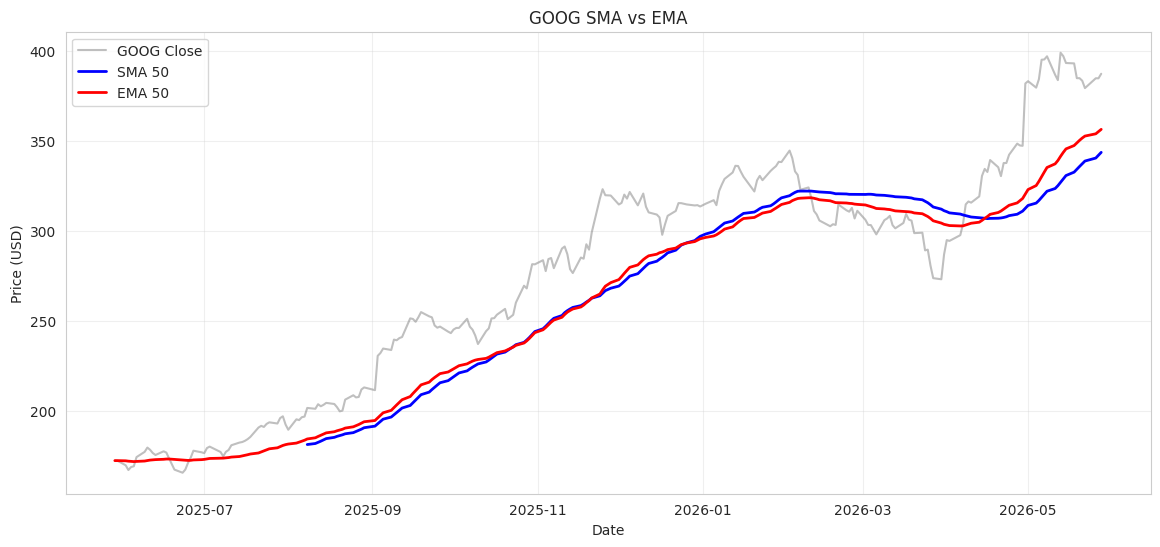

In [130]:
goog_1yr = data['GOOG'].last('365D').to_frame()

# Simple Moving Averages
goog_1yr['SMA_10'] = goog_1yr['GOOG'].rolling(window=10).mean()
goog_1yr['SMA_25'] = goog_1yr['GOOG'].rolling(window=25).mean()
goog_1yr['SMA_50'] = goog_1yr['GOOG'].rolling(window=50).mean()

# Exponential Moving Averages
goog_1yr['EMA_10'] = goog_1yr['GOOG'].ewm(span=10, adjust=False).mean()
goog_1yr['EMA_25'] = goog_1yr['GOOG'].ewm(span=25, adjust=False).mean()
goog_1yr['EMA_50'] = goog_1yr['GOOG'].ewm(span=50, adjust=False).mean()


plt.figure(figsize=(14,6))

plt.plot(goog_1yr['GOOG'], label='GOOG Close', color='gray', alpha=0.5)

plt.plot(goog_1yr['SMA_50'], label='SMA 50', color='blue', linewidth=2)

plt.plot(goog_1yr['EMA_50'], label='EMA 50', color='red', linewidth=2)

plt.title('GOOG SMA vs EMA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Insights

- The EMA reacts faster to recent price movements and stays closer to the actual GOOG closing price compared to the SMA.

- During sharp upward momentum phases, the EMA rises more quickly than the SMA, indicating stronger sensitivity to recent market trends.

- The SMA provides a smoother long-term trend line, reducing the impact of short-term market fluctuations and noise.

- The widening gap between EMA and SMA during strong rallies suggests increasing bullish momentum in GOOG stock.

- The recent upward movement of both EMA and SMA indicates continuation of a positive medium-term trend in GOOG.

## Risk & Return Analysis

### Daily Returns Distribution

Daily Return = (Today - Yesterday) / Yesterday

Wider distribution = more volatile = higher risk.


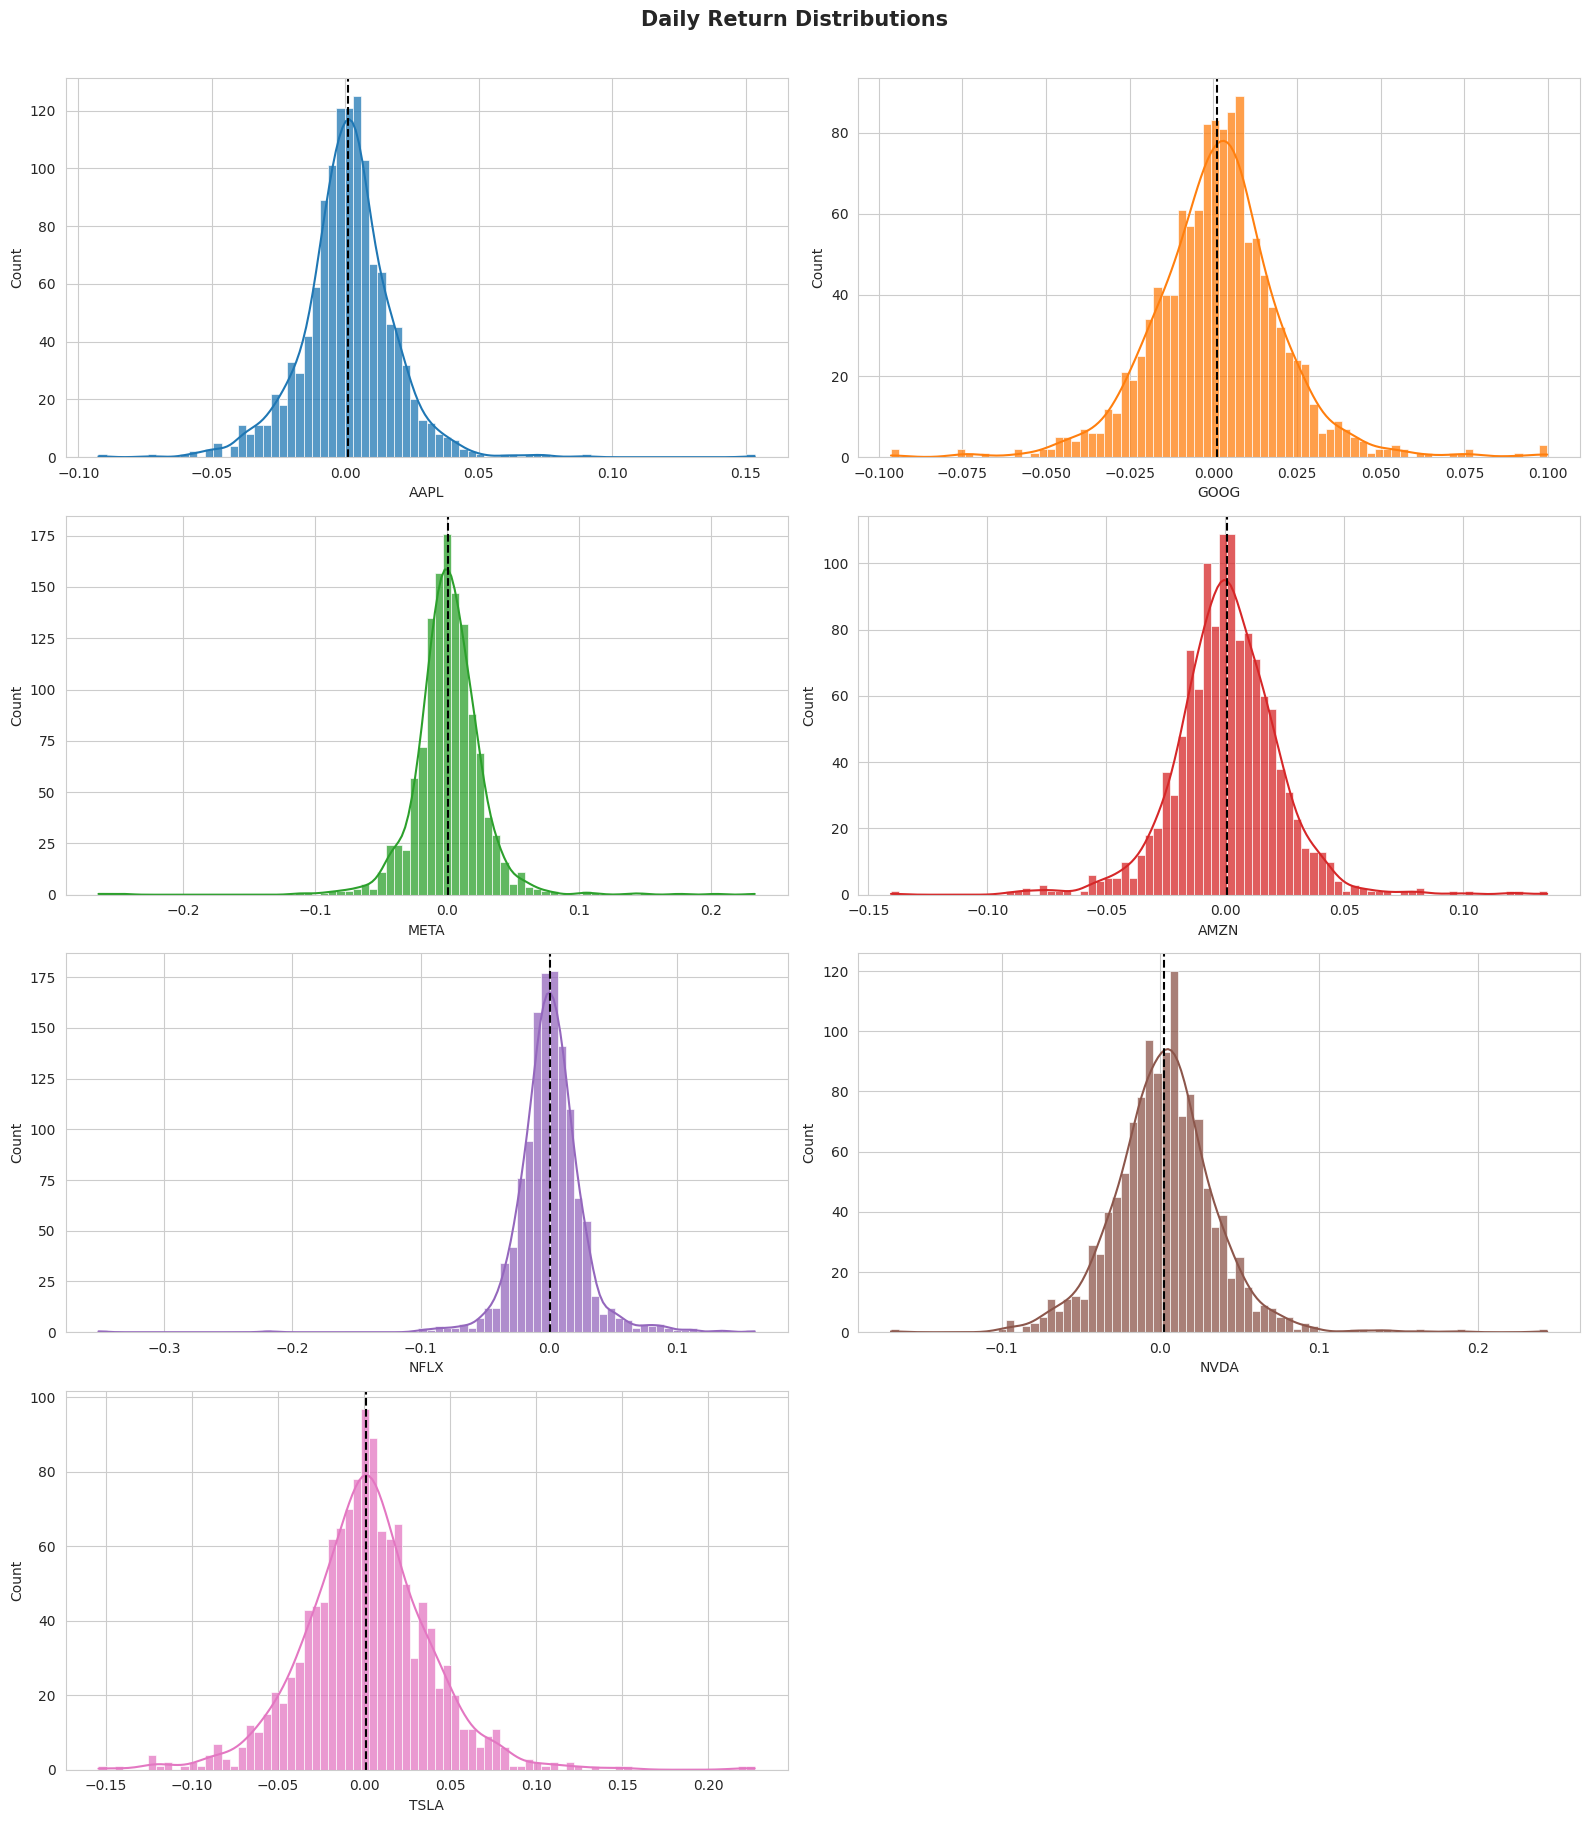

In [131]:
daily_returns = data.pct_change().dropna()

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, ticker in enumerate(tickers):

    sns.histplot(
        daily_returns[ticker],
        bins=80,
        kde=True,
        color=colors[i],
        alpha=0.75,
        edgecolor='white',
        ax=axes[i]
    )

    axes[i].axvline(
        daily_returns[ticker].mean(),
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Mean'
    )

fig.delaxes(axes[7])
plt.suptitle('Daily Return Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Insights

- Most daily returns are concentrated near zero, indicating that small day-to-day price fluctuations occur far more frequently than extreme movements.

- NVIDIA and Tesla exhibit the widest return distributions, reflecting significantly higher volatility and investment risk compared to other Magnificent 7 stocks.

- Apple and Google show relatively narrower and more symmetric distributions, suggesting comparatively stable daily price behavior.

- stocks which displays fat tails and extreme outliers, indicating occasional sharp market shocks and sudden price movements that deviate from a normal distribution.

- The mean daily return for most stocks remains slightly positive, consistent with their overall long-term upward growth trends.

## Normality Testing of Daily Returns

Financial models often assume stock returns follow a normal distribution.  
This section tests whether the daily returns of the Magnificent 7 stocks are statistically normally distributed using the D’Agostino-Pearson normality test.

A p-value below 0.05 indicates rejection of the normality assumption.

Normality Test (D'Agostino-Pearson K² Test)
---------------------------------------------
  AAPL : p=0.0000  →  Normal ✗
  GOOG : p=0.0000  →  Normal ✗
  META : p=0.0000  →  Normal ✗
  AMZN : p=0.0000  →  Normal ✗
  NFLX : p=0.0000  →  Normal ✗
  NVDA : p=0.0000  →  Normal ✗
  TSLA : p=0.0000  →  Normal ✗


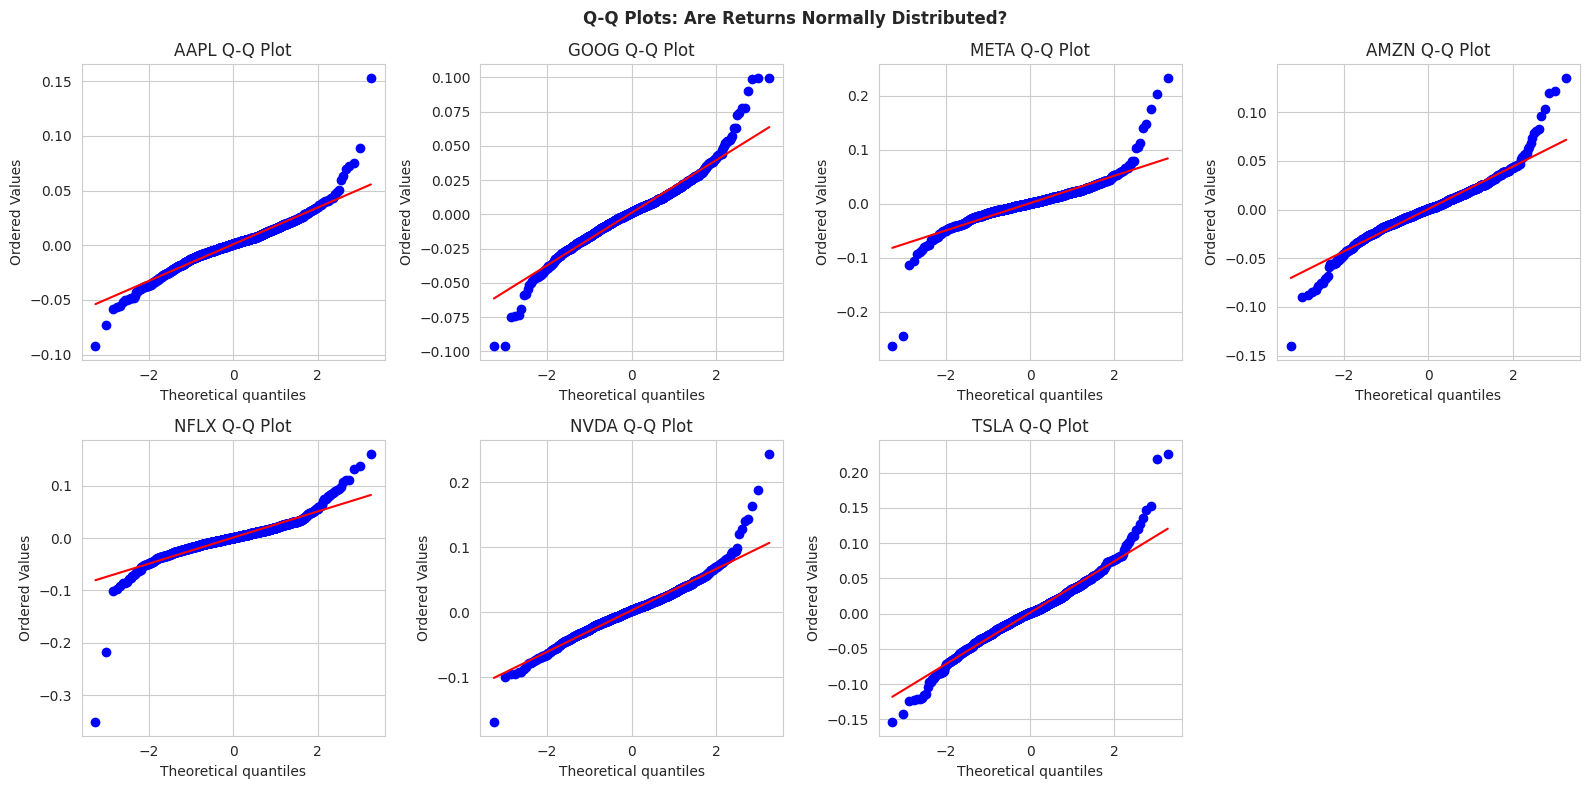

In [132]:
from scipy import stats

print("Normality Test (D'Agostino-Pearson K² Test)")
print("-" * 45)
for ticker in tickers:
    stat, p = stats.normaltest(daily_returns[ticker].dropna())
    result = "Normal ✗" if p < 0.05 else "Normal ✓"
    print(f"  {ticker:5s}: p={p:.4f}  →  {result}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    stats.probplot(daily_returns[ticker].dropna(), plot=axes[i])
    axes[i].set_title(f'{ticker} Q-Q Plot')
fig.delaxes(axes[7])
plt.suptitle('Q-Q Plots: Are Returns Normally Distributed?', fontweight='bold')
plt.tight_layout()
plt.show()

### INSIGHT
- p = 0.0000 for all 7 stocks — returns are definitively non-normal.
- S-curve in Q-Q plots = fat tails — extreme gains/losses occur far more frequently than a normal distribution would predict.
- TSLA & NFLX show the most deviation — occasional massive single-day moves that no normal model can capture.
- AAPL & GOOG stay closest to the red line — consistent with their lower volatility profile.
- Key implication: This justifies using GBM in Monte Carlo — log-normal assumption fits real financial data far better than normal.

### Risk vs Return Scatter Plot with Beta

- Annualized Return = Mean daily return x 252
- Annualized Volatility (Risk) = Std dev x sqrt(252)
- Beta (B): Sensitivity to market (S&P 500). B>1 means more volatile than market
- Sharpe Ratio = (Return - Risk-Free Rate) / Volatility

Ideal stock = Top-left corner (high return, low risk)


[*********************100%***********************]  1 of 1 completed


Risk-Return Summary:
      Annual Return (%)  Annual Volatility (%)   Beta  Sharpe Ratio
AAPL              22.66                  27.43  1.220         0.644
AMZN              16.93                  35.46  1.498         0.336
GOOG              28.43                  31.04  1.262         0.755
META              23.12                  43.90  1.618         0.413
NFLX              20.57                  43.10  1.232         0.361
NVDA              65.10                  51.62  2.155         1.164
TSLA              32.36                  58.89  2.009         0.465


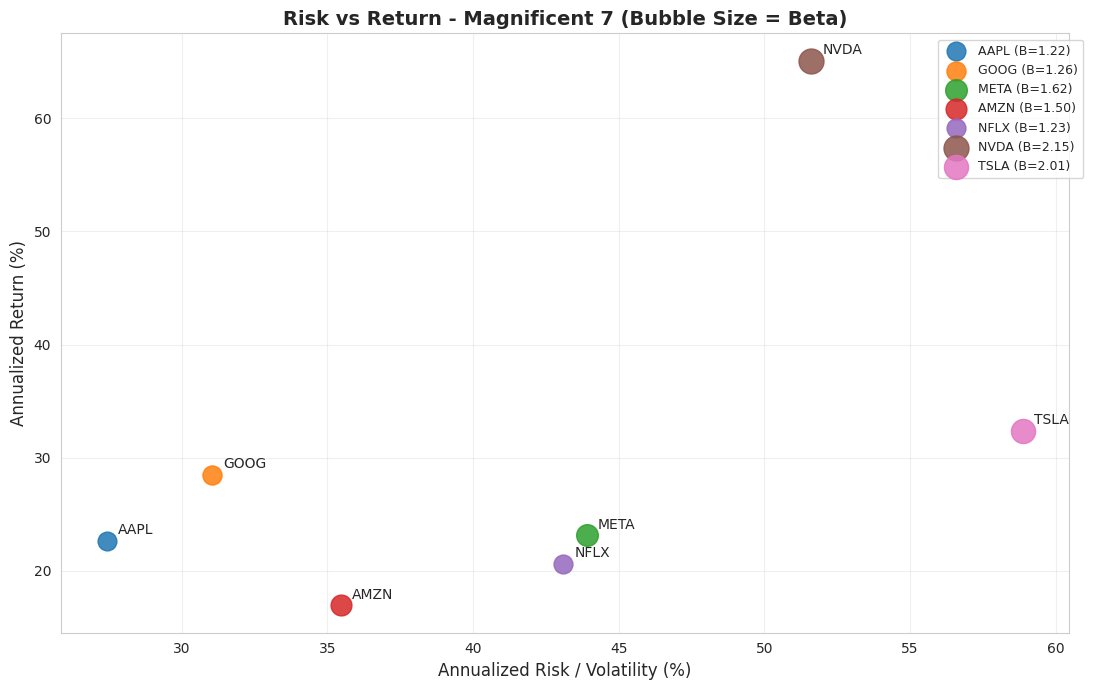

In [133]:
sp500 = yf.download('^GSPC', start=start_date, end=end_date)['Close']
market_returns = sp500.pct_change().dropna()

annual_returns = daily_returns.mean() * 252
annual_vol     = daily_returns.std()  * np.sqrt(252)
risk_free_rate = 0.05

def calculate_beta(stock_ret, mkt_ret):
    s, m = stock_ret.align(mkt_ret, join='inner')
    s, m = s.dropna(), m.dropna()
    s, m = s.align(m, join='inner')
    return np.cov(s, m)[0,1] / np.var(m)

betas = {t: calculate_beta(daily_returns[t], market_returns.squeeze()) for t in tickers}
sharpe_ratios = (annual_returns - risk_free_rate) / annual_vol

summary_df = pd.DataFrame({
    'Annual Return (%)':     (annual_returns * 100).round(2),
    'Annual Volatility (%)': (annual_vol * 100).round(2),
    'Beta':                  pd.Series(betas).round(3),
    'Sharpe Ratio':          sharpe_ratios.round(3)
})
print('Risk-Return Summary:')
print(summary_df.to_string())

plt.figure(figsize=(11, 7))
for i, ticker in enumerate(tickers):
    plt.scatter(annual_vol[ticker]*100, annual_returns[ticker]*100,
                s=betas[ticker]*150, color=colors[i], alpha=0.85,
                label=f'{ticker} (B={betas[ticker]:.2f})')
    plt.annotate(ticker, (annual_vol[ticker]*100, annual_returns[ticker]*100),
                 textcoords='offset points', xytext=(8, 5), fontsize=10)

plt.xlabel('Annualized Risk / Volatility (%)', fontsize=12)
plt.ylabel('Annualized Return (%)', fontsize=12)
plt.title('Risk vs Return - Magnificent 7 (Bubble Size = Beta)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights

- NVIDIA achieved the strongest overall performance, delivering the highest annualized return (65%) and the best Sharpe Ratio (1.16), indicating superior risk-adjusted returns despite its high volatility.

- Tesla exhibited the highest volatility and one of the largest beta values, confirming that it is the most aggressive and market-sensitive stock among the Magnificent 7.

- Apple and Google provided the most balanced risk-return profiles, combining comparatively lower volatility with stable long-term returns.

- Amazon and Netflix generated relatively weaker risk-adjusted performance, as their returns were not sufficiently high compared to the level of risk taken.

- Stocks with beta values significantly greater than 1, such as NVIDIA and Tesla, showed stronger sensitivity to overall market movements and larger price fluctuations.

### Correlation Heatmap

Correlation measures how similarly two stocks move together.

+1.0 = Move perfectly together
0.0 = No relationship
-1.0 = Move in opposite directions

High correlation among all 7 = limited diversification within this group alone.


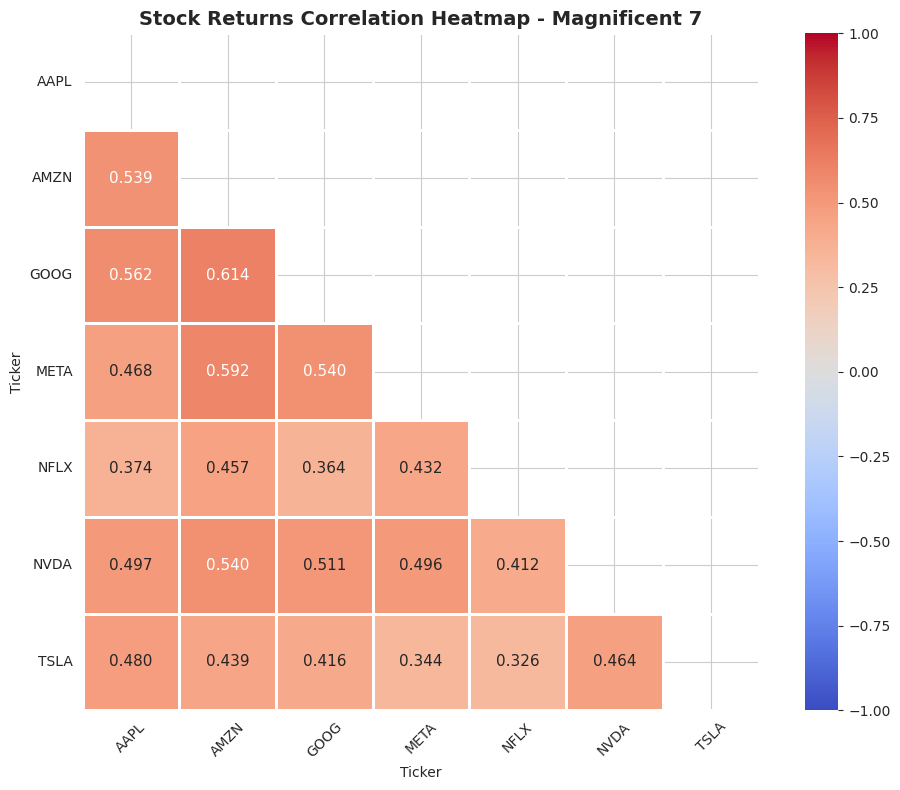

Highest correlated pair: AMZN & GOOG (0.614)
These two stocks tend to move most similarly.


In [134]:
corr_matrix = daily_returns.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 11}
)
plt.title('Stock Returns Correlation Heatmap - Magnificent 7', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_vals = corr_matrix.unstack()
corr_vals = corr_vals[corr_vals < 1.0].sort_values(ascending=False)
top_pair = corr_vals.index[0]
print(f'Highest correlated pair: {top_pair[0]} & {top_pair[1]} ({corr_vals.iloc[0]:.3f})')
print('These two stocks tend to move most similarly.')

### Key Insights

- All Magnificent 7 stocks exhibit positive correlations, indicating that they generally move in the same market direction and are influenced by similar macroeconomic and technology-sector trends.

- Amazon and Google show the highest correlation (0.614), suggesting that these companies respond most similarly to market conditions and investor sentiment.

- Tesla and Netflix demonstrate comparatively lower correlations with the rest of the group, indicating relatively more independent price behavior.

- Most correlations fall within the moderate range (0.3–0.6), implying that partial diversification benefits still exist within the Magnificent 7 portfolio.

- Despite some diversification potential, the overall positive correlation structure suggests that a portfolio concentrated entirely in large-cap technology stocks remains vulnerable to sector-wide downturns.



## Benchmark Comparison

The equal-weighted Magnificent 7 portfolio was compared against the S&P 500 and QQQ benchmarks to evaluate whether the portfolio outperformed both the broader market and the technology sector.

Alpha represents the excess return generated above the benchmark index.


In [135]:
# -----------------------------------
# Benchmark Comparison Preparation
# -----------------------------------

# Equal-weight M7 Portfolio
equal_weights = np.array([1/len(tickers)] * len(tickers))

m7_daily_ret = daily_returns.dot(equal_weights)

m7_c = (1 + m7_daily_ret).cumprod() * 100


# S&P 500 Benchmark
sp500 = yf.download('^GSPC', start=start_date, end=end_date)['Close']

sp500_aligned = sp500.reindex(data.index).ffill()

sp500_daily = sp500_aligned.pct_change().dropna()

sp5_c = (1 + sp500_daily).cumprod() * 100


# QQQ Benchmark
qqq = yf.download('QQQ', start=start_date, end=end_date)['Close']

qqq_aligned = qqq.reindex(data.index).ffill()

qqq_daily = qqq_aligned.pct_change().dropna()

qqq_c = (1 + qqq_daily).cumprod() * 100


# Align dates
m7_c, sp5_c = m7_c.align(sp5_c, join='inner')

m7_c, qqq_c = m7_c.align(qqq_c, join='inner')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


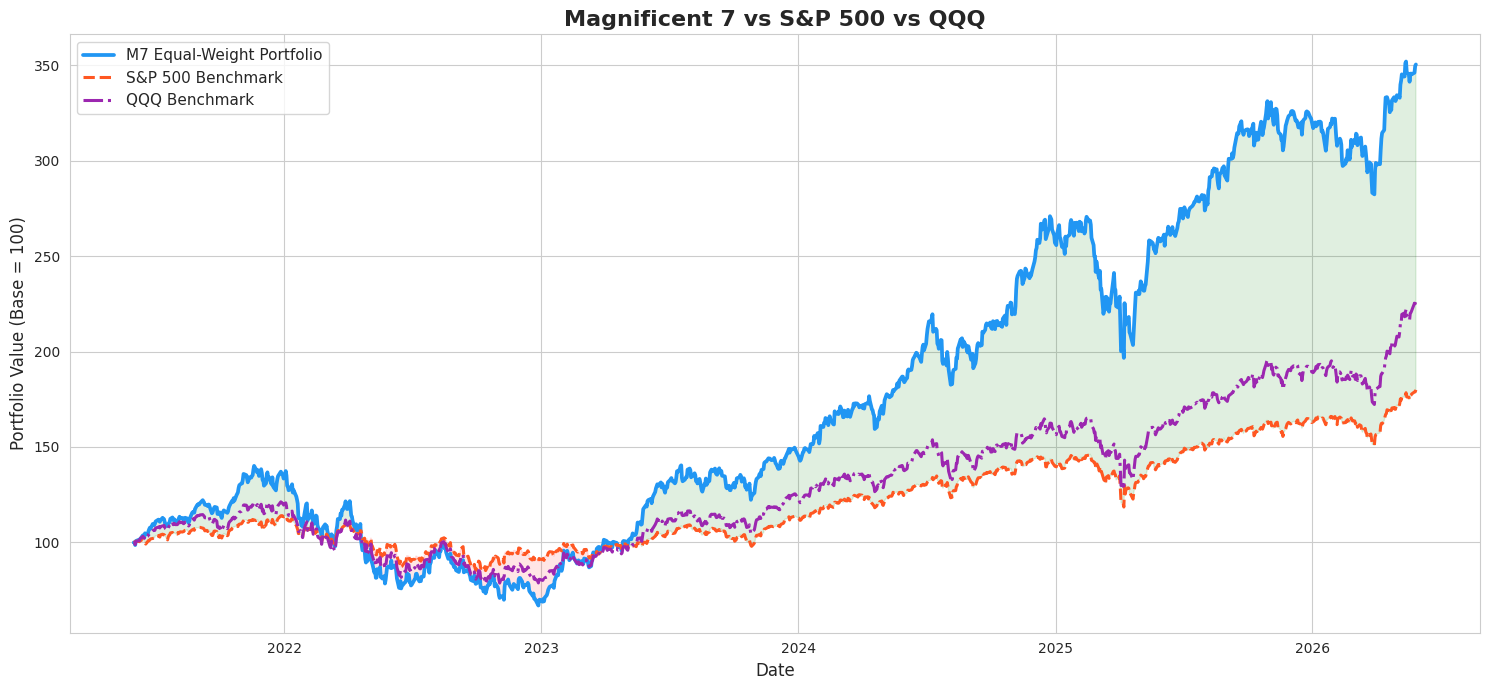


5-Year Cumulative Returns
----------------------------------------
M7 Portfolio : +250.5%
S&P 500      : +79.9%
QQQ ETF      : +127.1%

Alpha / Excess Returns
----------------------------------------
Alpha vs S&P 500 : +170.5%
Alpha vs QQQ     : +123.4%


In [136]:
plt.figure(figsize=(15,7))

# Seaborn Style
sns.set_style('whitegrid')

# M7 Portfolio
sns.lineplot(
    x=m7_c.index,
    y=m7_c.values.flatten(),
    label='M7 Equal-Weight Portfolio',
    linewidth=2.7,
    color='#2196F3'
)

# S&P 500
sns.lineplot(
    x=sp5_c.index,
    y=sp5_c.values.flatten(),
    label='S&P 500 Benchmark',
    linewidth=2.2,
    linestyle='--',
    color='#FF5722'
)

# QQQ
sns.lineplot(
    x=qqq_c.index,
    y=qqq_c.values.flatten(),
    label='QQQ Benchmark',
    linewidth=2.2,
    linestyle='-.',
    color='#9C27B0'
)

# Highlight Outperformance
plt.fill_between(
    m7_c.index,
    m7_c.values.flatten(),
    sp5_c.values.flatten(),
    where=(m7_c.values.flatten() >= sp5_c.values.flatten()),
    alpha=0.12,
    color='green'
)

# Highlight Underperformance
plt.fill_between(
    m7_c.index,
    m7_c.values.flatten(),
    sp5_c.values.flatten(),
    where=(m7_c.values.flatten() < sp5_c.values.flatten()),
    alpha=0.10,
    color='red'
)

plt.title(
    'Magnificent 7 vs S&P 500 vs QQQ',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Base = 100)', fontsize=12)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# -----------------------------
# Performance Summary
# -----------------------------

m7_return = m7_c.iloc[-1] - 100
sp500_ret = sp5_c.iloc[-1].item() - 100
qqq_ret   = qqq_c.iloc[-1].item() - 100

print('\n5-Year Cumulative Returns')
print('-' * 40)

print(f'M7 Portfolio : +{m7_return:.1f}%')
print(f'S&P 500      : +{sp500_ret:.1f}%')
print(f'QQQ ETF      : +{qqq_ret:.1f}%')

print('\nAlpha / Excess Returns')
print('-' * 40)

print(f'Alpha vs S&P 500 : {m7_return - sp500_ret:+.1f}%')
print(f'Alpha vs QQQ     : {m7_return - qqq_ret:+.1f}%')

### Insights

- The equal-weighted Magnificent 7 portfolio significantly outperformed both the broader S&P 500 index and the technology-heavy QQQ benchmark over the 5-year period.

- The M7 portfolio generated approximately +250% cumulative returns, compared to +79% for the S&P 500 and +127% for QQQ, highlighting the exceptional dominance of mega-cap technology stocks.

- Even against QQQ, which already contains many large-cap technology companies, the M7 portfolio delivered substantial excess returns, indicating strong concentration-driven outperformance.

- The portfolio experienced sharp drawdowns during the 2022 technology correction, but recovered aggressively from 2023 onward, largely driven by the AI-led rally in companies such as NVIDIA.

- The large positive alpha relative to both benchmarks suggests that the Magnificent 7 stocks benefited disproportionately from recent market enthusiasm surrounding artificial intelligence and large-cap growth sectors.

## Maximum Drawdown Analysis

Maximum Drawdown measures the largest percentage decline from a portfolio’s previous peak value. It helps evaluate downside risk and the severity of historical portfolio crashes.

In [137]:
# Function to calculate max drawdown
def max_drawdown(series):

    rolling_max = series.cummax()

    drawdown = (series - rolling_max) / rolling_max

    return drawdown.min() * 100


# Calculate drawdowns
m7_drawdown  = max_drawdown(m7_c)
sp500_drawdown = max_drawdown(sp5_c)
qqq_drawdown = max_drawdown(qqq_c)

print('Maximum Drawdown Analysis')
print('-' * 40)

print(f'M7 Portfolio : {m7_drawdown:.2f}%')
print(f'S&P 500      : {sp500_drawdown.item():.2f}%')
print(f'QQQ ETF       : {qqq_drawdown.item():.2f}%')

Maximum Drawdown Analysis
----------------------------------------
M7 Portfolio : -52.24%
S&P 500      : -25.43%
QQQ ETF       : -35.12%


### Insights

- The Magnificent 7 portfolio experienced substantially larger drawdowns than both the S&P 500 and QQQ, indicating higher downside risk and volatility.

- Despite delivering superior long-term returns, the M7 portfolio underwent severe short-term declines during market corrections, particularly during the 2022 tech selloff.

- The analysis highlights the tradeoff between higher returns and greater portfolio risk in concentrated technology-focused investments.

## CAPM Analysis

The Capital Asset Pricing Model (CAPM) estimates the expected return of a stock based on its systematic market risk (Beta).

Stocks with higher beta values are expected to generate higher returns as compensation for greater market exposure.

Alpha measures the difference between actual and CAPM-expected returns:
- Positive Alpha → stock outperformed its risk-adjusted expectation
- Negative Alpha → stock underperformed relative to its market risk

Risk-Free Rate used: ~5% (1-Year U.S. Treasury Yield)

CAPM Analysis Results:
        Beta  CAPM Expected Return (%)  Actual Return (%)  Alpha (%)
Stock                                                               
AAPL   1.220                     15.04              22.66       7.62
GOOG   1.262                     15.39              28.43      13.04
META   1.618                     18.32              23.12       4.79
AMZN   1.498                     17.34              16.93      -0.41
NFLX   1.232                     15.15              20.57       5.42
NVDA   2.155                     22.74              65.10      42.36
TSLA   2.009                     21.54              32.36      10.82


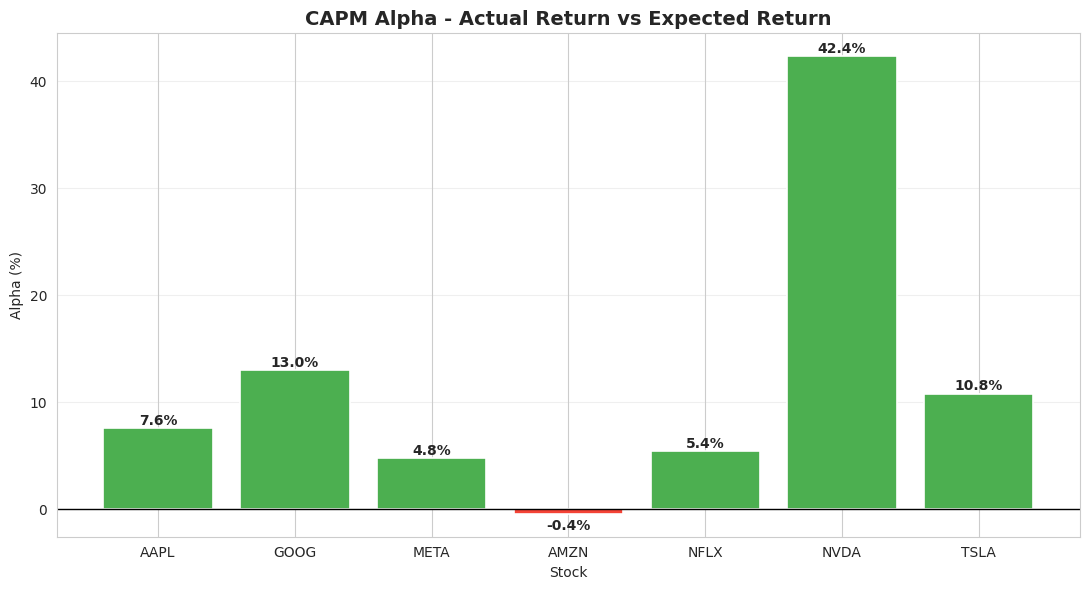

In [138]:
market_annual_return = market_returns.squeeze().mean() * 252

capm_results = []
for ticker in tickers:
    beta    = betas[ticker]
    exp_ret = risk_free_rate + beta * (market_annual_return - risk_free_rate)
    act_ret = annual_returns[ticker]
    alpha   = act_ret - exp_ret
    capm_results.append({
        'Stock': ticker,
        'Beta': round(beta, 3),
        'CAPM Expected Return (%)': round(exp_ret * 100, 2),
        'Actual Return (%)': round(act_ret * 100, 2),
        'Alpha (%)': round(alpha * 100, 2)
    })

capm_df = pd.DataFrame(capm_results).set_index('Stock')
print('CAPM Analysis Results:')
print(capm_df.to_string())

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#4CAF50' if x > 0 else '#F44336' for x in capm_df['Alpha (%)']]
bars = ax.bar(capm_df.index, capm_df['Alpha (%)'], color=bar_colors, edgecolor='white', linewidth=1.2)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('CAPM Alpha - Actual Return vs Expected Return', fontsize=14, fontweight='bold')
ax.set_ylabel('Alpha (%)')
ax.set_xlabel('Stock')
for bar, val in zip(bars, capm_df['Alpha (%)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.3 if val >= 0 else -1.5),
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Key Insights

- NVIDIA generated the highest positive alpha by a substantial margin, indicating that its returns far exceeded what CAPM predicted based on its market risk exposure.

- Most Magnificent 7 stocks delivered positive alpha, suggesting that they outperformed their risk-adjusted expected returns during the analysis period.

- Amazon was the only stock with slightly negative alpha, implying that its returns were marginally lower than what its beta-based risk level would justify.

- The analysis highlights that strong absolute returns alone are insufficient; evaluating performance relative to market risk provides a more accurate assessment of stock efficiency.

## Portfolio Optimization using Modern Portfolio Theory (MPT)

MPT combining assets with different risk-return characteristics can create portfolios with improved risk-adjusted performance through diversification.

To identify efficient portfolios, 20,000 random portfolio weight combinations were simulated using the Magnificent 7 stocks.

For each portfolio, the following metrics were calculated:
- Expected Annual Return
- Annualized Volatility (Risk)
- Sharpe Ratio

The collection of simulated portfolios forms the Efficient Frontier, representing portfolios that provide the highest expected return for a given level of risk.

The portfolio with the highest Sharpe Ratio is considered the optimal risk-adjusted portfolio.

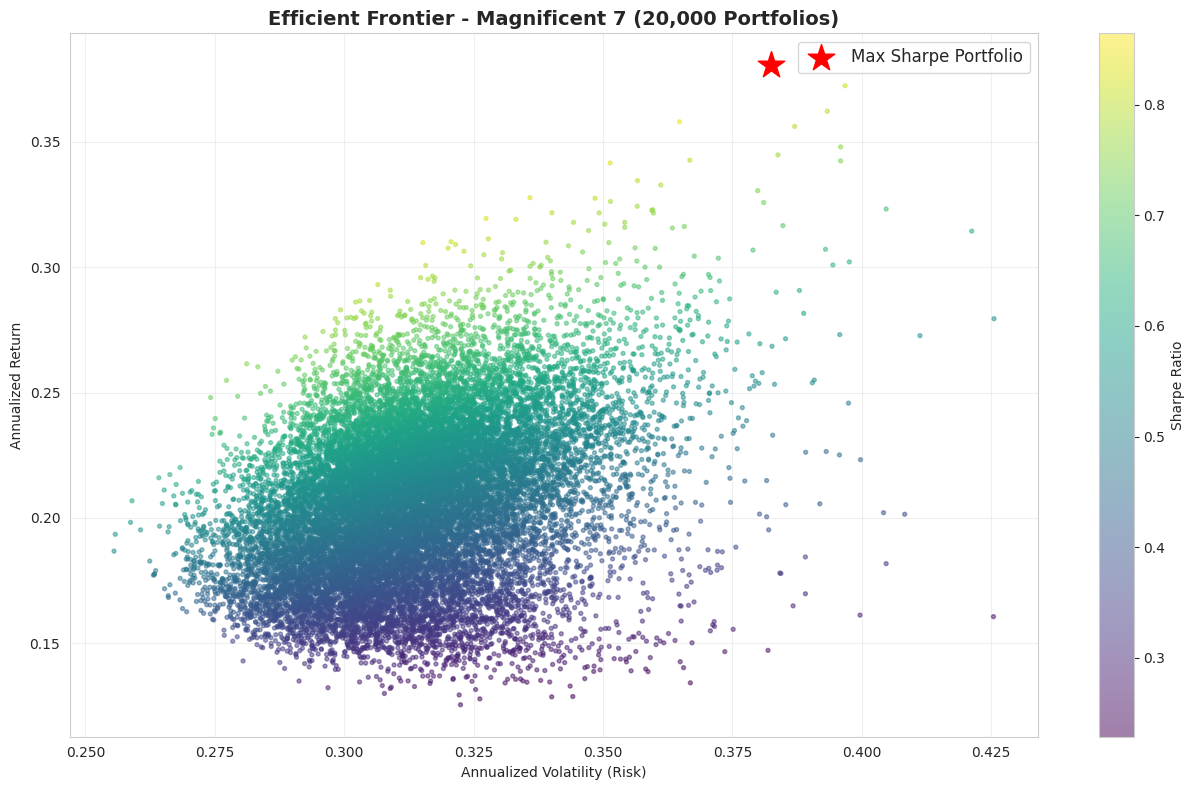

Optimal Portfolio (Maximum Sharpe Ratio):
   Annualized Return    : 38.06%
   Annualized Volatility: 38.25%
   Sharpe Ratio         : 0.864

Optimal Weights:
   AAPL : 12.47%
   GOOG : 0.89%
   META : 14.30%
   AMZN : 2.29%
   NFLX : 5.85%
   NVDA : 58.70%
   TSLA : 5.49%


In [139]:
log_returns    = np.log(data / data.shift(1)).dropna()
mean_log_ret   = log_returns.mean()
cov_mat        = log_returns.cov()
num_portfolios = 20000

results        = np.zeros((3, num_portfolios))
weights_record = []
np.random.seed(42)

for i in range(num_portfolios):
    w  = np.random.random(len(tickers))
    w /= np.sum(w)
    weights_record.append(w)
    p_ret = np.sum(mean_log_ret * w) * 252
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat * 252, w)))
    results[0, i] = p_ret
    results[1, i] = p_vol
    results[2, i] = (p_ret - risk_free_rate) / p_vol

results_df     = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe Ratio'])
max_sharpe_idx = results_df['Sharpe Ratio'].idxmax()
max_sharpe     = results_df.loc[max_sharpe_idx]
optimal_weights = pd.Series(weights_record[max_sharpe_idx], index=tickers)

plt.figure(figsize=(13, 8))
sc = plt.scatter(results_df['Volatility'], results_df['Return'],
                  c=results_df['Sharpe Ratio'], cmap='viridis', s=8, alpha=0.5)
plt.colorbar(sc, label='Sharpe Ratio')
plt.scatter(max_sharpe['Volatility'], max_sharpe['Return'],
             color='red', marker='*', s=400, zorder=5, label='Max Sharpe Portfolio')
plt.title('Efficient Frontier - Magnificent 7 (20,000 Portfolios)', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Optimal Portfolio (Maximum Sharpe Ratio):')
print(f'   Annualized Return    : {max_sharpe["Return"]*100:.2f}%')
print(f'   Annualized Volatility: {max_sharpe["Volatility"]*100:.2f}%')
print(f'   Sharpe Ratio         : {max_sharpe["Sharpe Ratio"]:.3f}')
print('\nOptimal Weights:')
for t, w in optimal_weights.items():
    print(f'   {t:5s}: {w*100:.2f}%')

### Key Insights

- Combining multiple stocks helped reduce overall portfolio risk and improved portfolio stability.

- The portfolio with the highest Sharpe Ratio provided the best balance between return and risk.

- Portfolios with higher returns also showed higher volatility, indicating greater investment risk.

- A diversified portfolio performed more efficiently than investing heavily in a single stock.

- Extremely risky portfolios did not always deliver the best risk-adjusted returns.

## Individual Stock Monte Carlo Simulation (GBM)

This section simulates 10,000 possible future price paths for NVDA using Geometric Brownian Motion (GBM) based on historical return and volatility.

The simulation helps estimate future uncertainty, downside risk, and probable price ranges under different market conditions.

99% Value at Risk (VaR) is also calculated to estimate the potential worst-case loss under extreme scenarios.

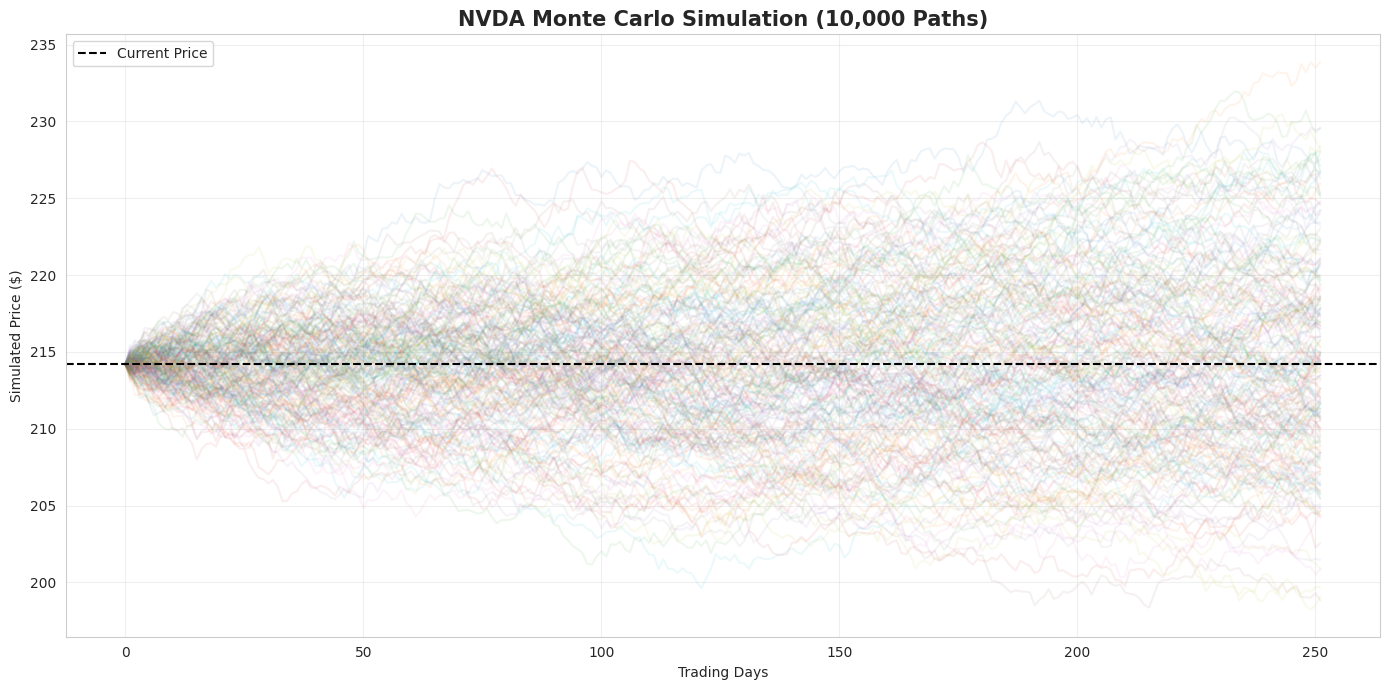

99% Value at Risk (VaR) for NVDA: -7.09%


In [140]:
# -----------------------------------
# Individual Stock Monte Carlo (GBM)
# -----------------------------------

stock = 'NVDA'

log_ret = np.log(data[stock] / data[stock].shift(1)).dropna()

mu    = log_ret.mean()
sigma = log_ret.std()

S0 = data[stock].iloc[-1]

T = 252
N = 10000

dt = 1/252

simulations = np.zeros((T, N))

simulations[0] = S0

for t in range(1, T):

    z = np.random.standard_normal(N)

    simulations[t] = simulations[t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt +
        sigma * np.sqrt(dt) * z
    )

# 99% VaR
final_prices = simulations[-1]

returns = (final_prices - S0) / S0 * 100

var_99 = np.percentile(returns, 1)

# Plot
plt.figure(figsize=(14,7))

plt.plot(simulations[:, :200], alpha=0.08)

plt.axhline(S0, color='black', linestyle='--', label='Current Price')

plt.title(
    f'{stock} Monte Carlo Simulation (10,000 Paths)',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Trading Days')

plt.ylabel('Simulated Price ($)')

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print(f'99% Value at Risk (VaR) for {stock}: {var_99:.2f}%')

### Key Insights

* The Monte Carlo simulation shows a wide range of possible future NVDA price paths, highlighting the high uncertainty and volatility associated with the stock.

* Most simulated paths remain above the current price over the one-year horizon, indicating a positive long-term growth expectation based on historical trends.

* The 99% VaR of approximately -7% suggests that, under extreme market conditions, NVDA is expected to lose more than 7% in only 1% of simulated scenarios.


## Monte Carlo Risk Simulation

Monte Carlo simulation was used to model thousands of possible future portfolio paths under market uncertainty using Geometric Brownian Motion (GBM).

The simulation incorporates:
- Expected returns (drift)
- Volatility
- Random market shocks

To preserve realistic relationships between stocks, Cholesky Decomposition was applied to the covariance matrix so that simulated asset returns maintain historical correlations.

This approach provides a probabilistic view of potential future portfolio performance and downside risk.

In [141]:
def portfolio_monte_carlo(log_rets, cholesky, start_prices, days, n_sims):
    """Simulate correlated portfolio paths using GBM + Cholesky decomposition."""
    n_stocks = len(start_prices)
    sims = np.zeros((days, n_sims, n_stocks))
    sims[0] = start_prices
    drift = log_rets.mean().values - 0.5 * log_rets.var().values
    for t in range(1, days):
        Z      = np.random.normal(0, 1, (n_sims, n_stocks))
        corr_Z = Z @ cholesky.T
        sims[t] = sims[t-1] * np.exp(drift + corr_Z)
    return sims

start_prices    = data.iloc[-1].values
cov_matrix_mc   = log_returns.cov()
cholesky_decomp = np.linalg.cholesky(cov_matrix_mc)
days_to_simulate = 252
num_simulations  = 10000

print(f'Running {num_simulations:,} simulations for {days_to_simulate} trading days...')
portfolio_sims = portfolio_monte_carlo(log_returns, cholesky_decomp, start_prices, days_to_simulate, num_simulations)
print(f'Done! Shape: {portfolio_sims.shape}  (days x simulations x stocks)')

Running 10,000 simulations for 252 trading days...
Done! Shape: (252, 10000, 7)  (days x simulations x stocks)


###  Visualizing Simulated Price Paths (AAPL)


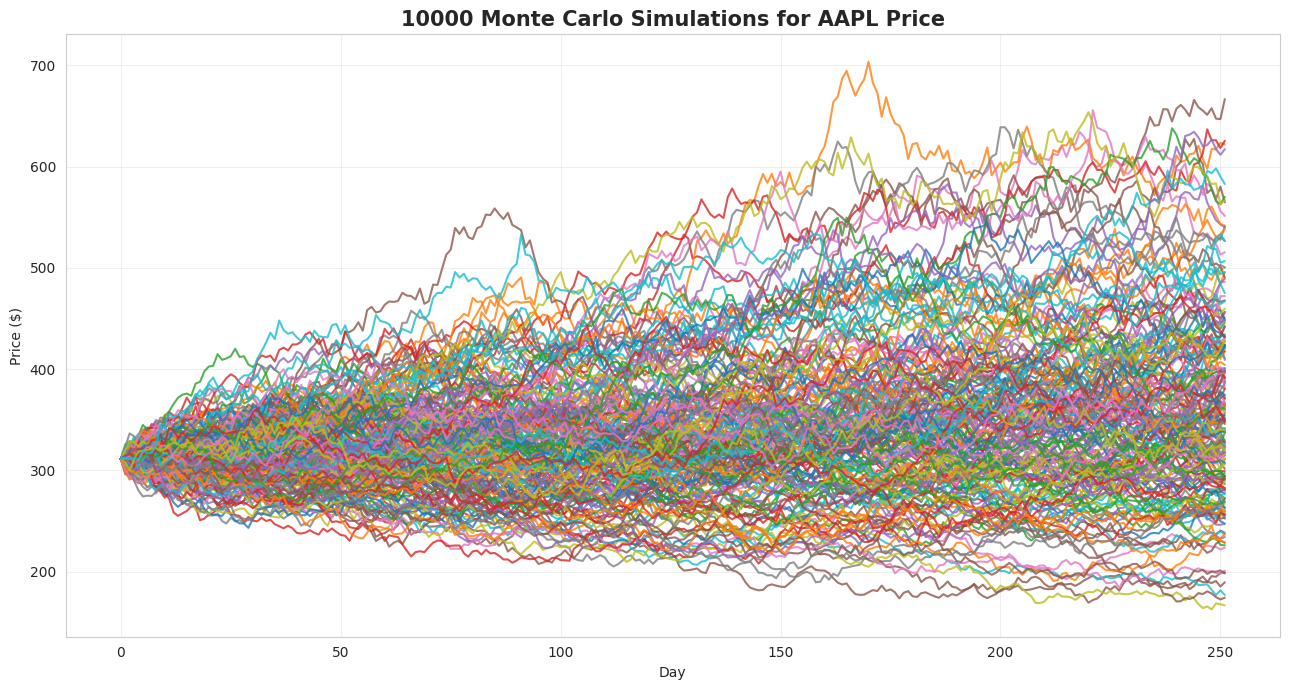

In [142]:
stock_idx  = tickers.index('AAPL')
stock_name = 'AAPL'

plt.figure(figsize=(13,7))

# Multiple colorful simulation paths
for i in range(200):
    plt.plot(
        portfolio_sims[:, i, stock_idx],
        linewidth=1.5,
        alpha=0.8
    )

plt.title(f'10000 Monte Carlo Simulations for {stock_name} Price',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Day')
plt.ylabel('Price ($)')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Insight
* The majority of simulated paths show an upward trend, suggesting positive long-term growth potential for AAPL based on historical market behavior.

* The widening spread of simulation paths over time indicates that uncertainty and volatility increase significantly in long-term forecasting.

* Monte Carlo simulation highlights both upside opportunities and downside risks, making it useful for probabilistic risk analysis instead of exact price prediction.


###  Value at Risk (VaR) Comparison

Value at Risk (VaR) answers:
What is the maximum loss we should expect with X% confidence over the next year?

We compare VaR for two strategies:
1. Equal-Weight Portfolio: 1/7 in each stock
2. Optimal Portfolio: weights from Efficient Frontier (max Sharpe)


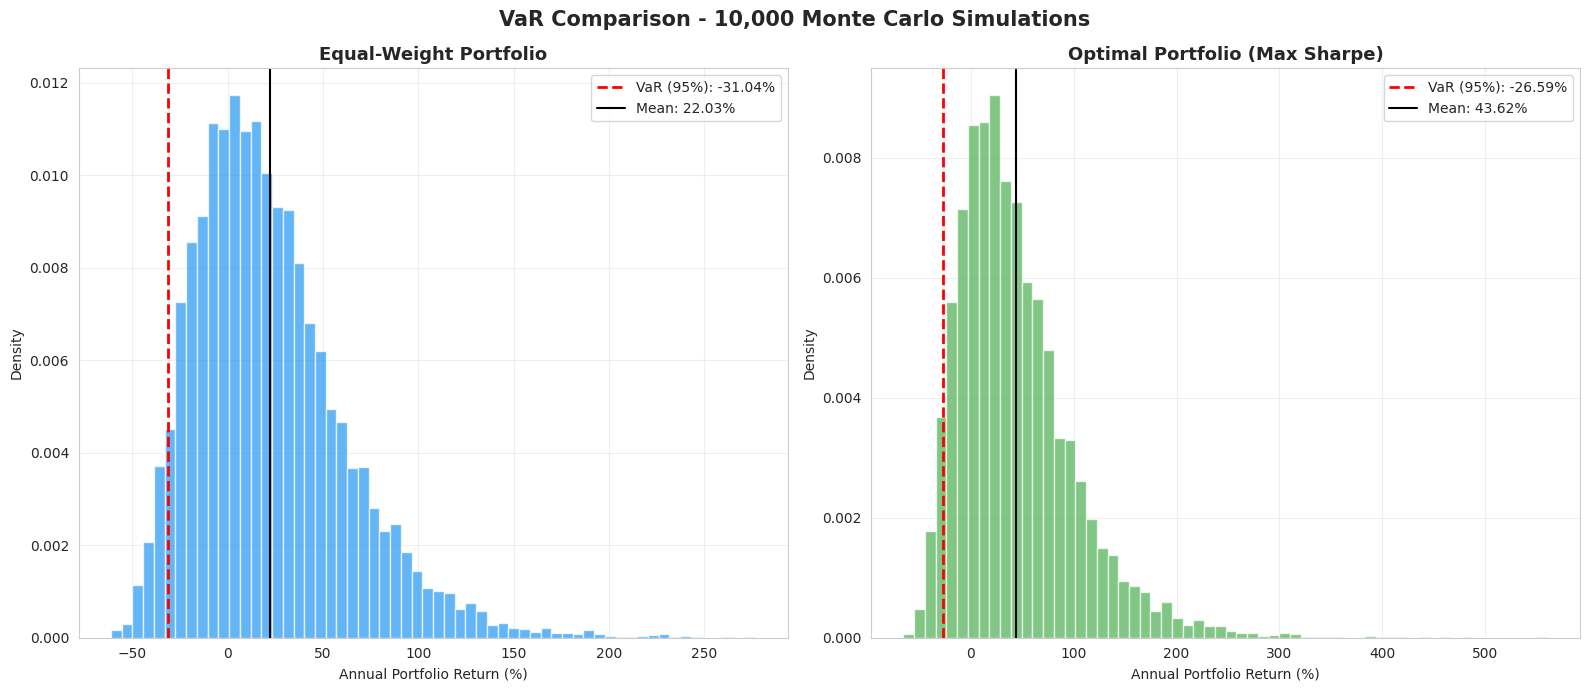

VaR Results:
  Equal-Weight Portfolio : 95% VaR = -31.04%
  Optimal Portfolio      : 95% VaR = -26.59%
  Result: Optimal portfolio REDUCES downside risk by 4.45%

Interpretation: With 95% confidence, the equal-weight portfolio
will not lose more than 31.04% of its value in the next year.


In [143]:
def get_var(sims, weights, prices, conf=0.95):
    initial = np.sum(prices * weights)
    final   = np.sum(sims[-1] * weights, axis=1)
    rets    = (final - initial) / initial * 100
    var     = np.percentile(rets, 100*(1-conf))
    return var, rets

equal_w   = np.array([1/len(tickers)] * len(tickers))
optimal_w = optimal_weights.values

var_equal,   rets_equal   = get_var(portfolio_sims, equal_w,   start_prices)
var_optimal, rets_optimal = get_var(portfolio_sims, optimal_w, start_prices)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, rets, var, title, color in [
    (ax1, rets_equal,   var_equal,   'Equal-Weight Portfolio',        '#2196F3'),
    (ax2, rets_optimal, var_optimal, 'Optimal Portfolio (Max Sharpe)', '#4CAF50')
]:
    ax.hist(rets, bins=60, color=color, alpha=0.7, edgecolor='white', density=True)
    ax.axvline(var, color='red', linestyle='--', linewidth=2, label=f'VaR (95%): {var:.2f}%')
    ax.axvline(np.mean(rets), color='black', linewidth=1.5, label=f'Mean: {np.mean(rets):.2f}%')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Annual Portfolio Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('VaR Comparison - 10,000 Monte Carlo Simulations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('VaR Results:')
print(f'  Equal-Weight Portfolio : 95% VaR = {var_equal:.2f}%')
print(f'  Optimal Portfolio      : 95% VaR = {var_optimal:.2f}%')
improvement = var_optimal - var_equal
if improvement > 0:
    print(f'  Result: Optimal portfolio REDUCES downside risk by {improvement:.2f}%')
print(f'\nInterpretation: With 95% confidence, the equal-weight portfolio')
print(f'will not lose more than {abs(var_equal):.2f}% of its value in the next year.')

## Rebalancing Backtest: Monthly Rebalancing vs Buy & Hold

This section compares two portfolio strategies to analyze whether periodic rebalancing improves portfolio performance and risk management.

* **Buy & Hold:** Invest once with equal weights and hold without changing allocations.
* **Monthly Rebalancing:** Reset portfolio weights to equal allocation every month.

Rebalancing helps maintain diversification and enforces a disciplined sell-high-buy-low strategy, but it may reduce gains during strong bullish trends by trimming winning stocks too early.


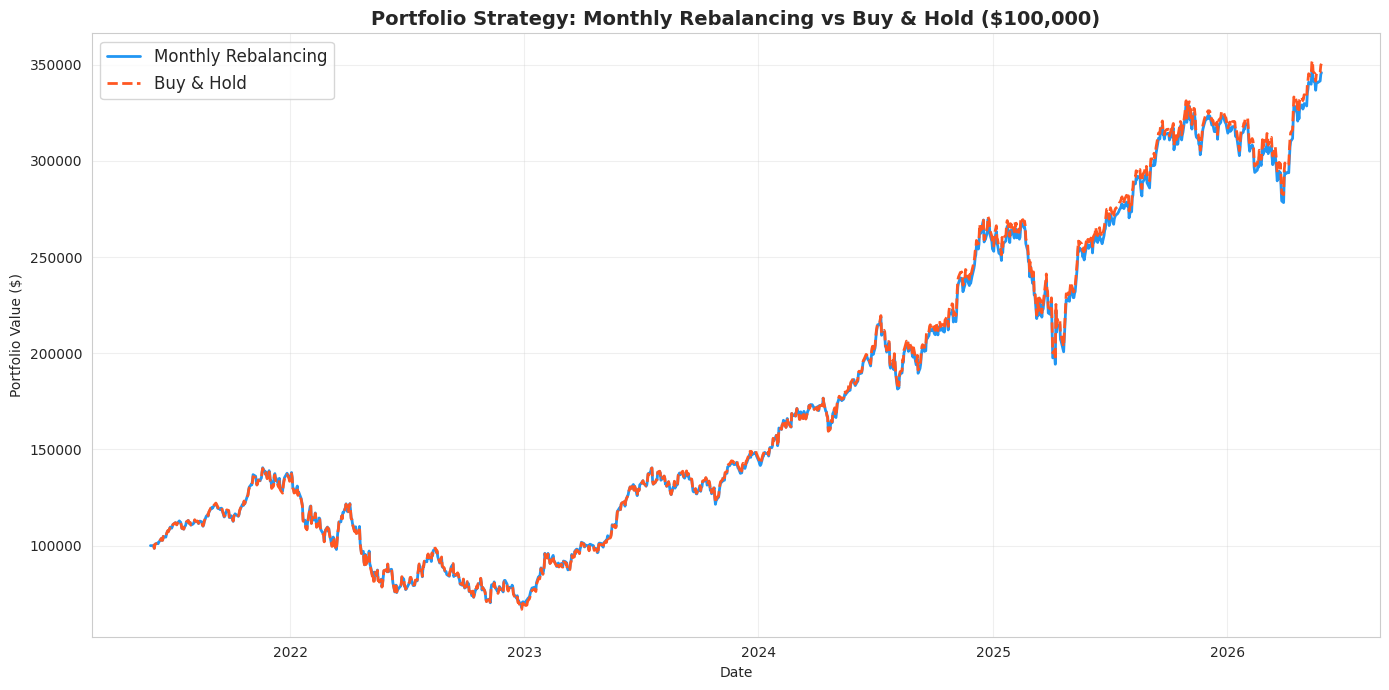

Final Portfolio Values (5 Years):
   Monthly Rebalancing: $345,812  (+245.8%)
   Buy & Hold         : $350,455  (+250.5%)


In [144]:
initial_capital = 100000.0
target_w        = np.array([1/len(tickers)] * len(tickers))
rebalance_dates = set(data.resample('ME').last().index)

portfolio_val = pd.Series(index=data.index, dtype=float)
shares        = pd.Series(0.0, index=tickers)
cash          = initial_capital

for i, date in enumerate(data.index):
    cp = data.loc[date]
    if i == 0 or date in rebalance_dates:
        total_val = cash if i == 0 else (shares * cp).sum() + cash
        shares    = (total_val * target_w) / cp
        cash      = 0.0
    portfolio_val[date] = (shares * cp).sum() + cash

bh_rets   = data.pct_change().dropna().dot(target_w)
bh_values = initial_capital * (1 + bh_rets).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(portfolio_val.index, portfolio_val.values, label='Monthly Rebalancing', color='#2196F3', linewidth=2)
plt.plot(bh_values.index,     bh_values.values,     label='Buy & Hold',          color='#FF5722', linewidth=2, linestyle='--')
plt.title('Portfolio Strategy: Monthly Rebalancing vs Buy & Hold ($100,000)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rebal_ret = (portfolio_val.iloc[-1] / initial_capital - 1) * 100
bh_ret    = (bh_values.iloc[-1]    / initial_capital - 1) * 100
print(f'Final Portfolio Values (5 Years):')
print(f'   Monthly Rebalancing: ${portfolio_val.iloc[-1]:,.0f}  ({rebal_ret:+.1f}%)')
print(f'   Buy & Hold         : ${bh_values.iloc[-1]:,.0f}  ({bh_ret:+.1f}%)')

## Insights
* Both strategies delivered very similar long-term performance, indicating that periodic rebalancing did not significantly reduce overall returns.

* Buy & Hold slightly outperformed due to allowing strong-performing stocks to continue growing without allocation constraints.

* Monthly rebalancing helped maintain diversification and portfolio discipline by preventing excessive concentration in a few high-performing stocks.
